In [ ]:
# FAZA 4 — Modelovanje: klasični modeli
#
# Treniram i poredim modele na tri nivoa selekcije atributa (pun skup, posle
# filtera, finalni). Sve odluke se donose na validacionom skupu. Test skup se
# priprema, ali se ne dira, koristi se tek na kraju Faze 6 jednom za finalnu
# evaluaciju svih modela.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
MODELS = Path(__file__).resolve().parent.parent / "models"
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

SEED = 7

In [ ]:
# --- 1. Učitavanje podataka iz Faze 3 ---
vremenski_prozori = pd.read_parquet(PROC / "features.parquet")

with open(PROC / "features_full.json", encoding="utf-8") as f:
    atributi_full = json.load(f)
with open(PROC / "features_after_filter.json", encoding="utf-8") as f:
    atributi_filter = json.load(f)
with open(PROC / "selected_features.json", encoding="utf-8") as f:
    atributi_final = json.load(f)
with open(PROC / "imputation_values.json", encoding="utf-8") as f:
    imputation_values = json.load(f)

print("Ukupno redova:", len(vremenski_prozori))
print(f"Full: {len(atributi_full)} atributa")
print(f"Filter: {len(atributi_filter)} atributa")
print(f"Final: {len(atributi_final)} atributa")

Ukupno redova: 224180
Full: 53 atributa
Filter: 40 atributa
Final: 12 atributa


In [ ]:
# --- 2. Priprema X i y za sva tri skupa (train/val/test) i sva tri nivoa atributa ---
# has_history je napravljen u Fazi 3 samo na treningu i nije sačuvan u
# features.parquet, pa se rekreira za sve redove po istom pravilu.
vremenski_prozori["has_history"] = (vremenski_prozori["window_seq_num"] >= 1).astype(
    int
)

# Imputacija koristi vrednosti izračunate na treningu (Faza 3), bez ponovnog
# računanja
for kolona, vrednost in imputation_values.items():
    if kolona in vremenski_prozori.columns:
        vremenski_prozori[kolona] = vremenski_prozori[kolona].fillna(vrednost)

train = vremenski_prozori[vremenski_prozori["split"] == "train"].reset_index(drop=True)
val = vremenski_prozori[vremenski_prozori["split"] == "valid"].reset_index(drop=True)
test = vremenski_prozori[vremenski_prozori["split"] == "test"].reset_index(drop=True)

y_train = train["is_attack"]
y_val = val["is_attack"]
y_test = test["is_attack"]

print(
    f"train: {len(train)} redova, {int(y_train.sum())} pozitivnih ({y_train.mean() * 100:.3f}%)"
)
print(
    f"val: {len(val)} redova, {int(y_val.sum())} pozitivnih ({y_val.mean() * 100:.3f}%)"
)
print(
    f"test: {len(test)} redova, {int(y_test.sum())} pozitivnih ({y_test.mean() * 100:.3f}%)"
)

# Promenljive X_train/X_val/X_test za svaki od tri nivoa selekcije atributa
X_train_full = train[atributi_full]
X_train_filter = train[atributi_filter]
X_train_final = train[atributi_final]

X_val_full = val[atributi_full]
X_val_filter = val[atributi_filter]
X_val_final = val[atributi_final]

X_test_full = test[atributi_full]
X_test_filter = test[atributi_filter]
X_test_final = test[atributi_final]

datasets = {
    f"Full ({len(atributi_full)})": {"X_train": X_train_full, "X_val": X_val_full},
    f"Filter ({len(atributi_filter)})": {
        "X_train": X_train_filter,
        "X_val": X_val_filter,
    },
    f"Final ({len(atributi_final)})": {"X_train": X_train_final, "X_val": X_val_final},
}

# Provera da posle imputacije ni u jednom skupu nema NaN
for naziv, d in datasets.items():
    n_nan = d["X_train"].isna().sum().sum() + d["X_val"].isna().sum().sum()
    assert n_nan == 0, f"NaN preostali u skupu {naziv}: {n_nan}"
print("\nNema preostalih NaN vrednosti ni u jednom skupu atributa.")

train: 45685 redova, 101 pozitivnih (0.221%)
val: 17630 redova, 115 pozitivnih (0.652%)
test: 160865 redova, 35 pozitivnih (0.022%)

Nema preostalih NaN vrednosti ni u jednom skupu atributa.


In [ ]:
# --- 3. Definicija modela ---
# Pipeline se koristi samo za modele osetljive na razmeru (logistička regresija,
# KNN).
# class_weight="balanced" / scale_pos_weight služe za
# disbalans, bez njih bi model predviđao samo negativnu klasu.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight za XGBoost: {scale_pos_weight:.1f}")


def make_models(balansiranje=True):
    """Vraća rečnik modela."""
    cw = "balanced" if balansiranje else None
    spw = scale_pos_weight if balansiranje else 1
    return {
        "Dummy": DummyClassifier(strategy="stratified", random_state=SEED),
        "LogReg": Pipeline(
            [
                ("scaler", RobustScaler()),
                (
                    "model",
                    LogisticRegression(
                        class_weight=cw, max_iter=1000, random_state=SEED
                    ),
                ),
            ]
        ),
        "KNN": Pipeline(
            [
                ("scaler", RobustScaler()),
                ("model", KNeighborsClassifier()),
            ]
        ),
        "DecisionTree": DecisionTreeClassifier(class_weight=cw, random_state=SEED),
        "RandomForest": RandomForestClassifier(
            class_weight=cw, random_state=SEED, n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            scale_pos_weight=spw, eval_metric="aucpr", random_state=SEED, n_jobs=-1
        ),
    }


def evaluate_model(model, X_tr, y_tr, X_v, y_v):
    """Trenira model i vraća Average Precision na treningu i validaciji."""
    model.fit(X_tr, y_tr)
    p_tr = model.predict_proba(X_tr)[:, 1]
    p_v = model.predict_proba(X_v)[:, 1]
    return (
        average_precision_score(y_tr, p_tr),
        average_precision_score(y_v, p_v),
        roc_auc_score(y_v, p_v),
    )


# Definisano šest modela (Dummy, LogReg, KNN, DecisionTree, RandomForest,
# XGBoost).
# scale_pos_weight = 451.3 potvrđuje ranije izmereni disbalans, provera
# pre nego što se broj prosledi XGBoost-u.

scale_pos_weight za XGBoost: 451.3


In [ ]:
# --- 4. Baseline modeli kroz tri skupa atributa ---
# Svi modeli su sa podrazumevanim hiperparametrima uz primenu
# balansiranja klasa. Tuning sledi tek za najbolji model.
BASELINE = ["Dummy", "LogReg", "KNN", "DecisionTree"]

rezultati = []
for naziv_skupa, d in datasets.items():
    modeli = make_models(balansiranje=True)
    for naziv_modela in BASELINE:
        ap_tr, ap_v, auc_v = evaluate_model(
            modeli[naziv_modela], d["X_train"], y_train, d["X_val"], y_val
        )
        rezultati.append(
            {
                "Skup": naziv_skupa,
                "Model": naziv_modela,
                "AP train": round(ap_tr, 4),
                "AP val": round(ap_v, 4),
                "AUC-ROC val": round(auc_v, 4),
            }
        )

baseline_rezultati = pd.DataFrame(rezultati)
print("Baseline modeli:")
print(baseline_rezultati.to_string(index=False))

# Dummy potvrđuje teorijsko očekivanje: AP na validacionom skupu (0.0065) skoro
# tačno odgovara udelu pozitivnih na istom skupu. Log Reg jedini ubedljivo
# pobeđuje Dummy kroz sva tri skupa atributa i najbolji je
# na Final skupu (AP=0.076) što potvrđuje da je selekcija atributa bila korisna.
# KNN i posebno Decision Tree pokazuju jasan overfitting. Decision Tree očekivano
# overfit-uje, na train-u AP = 1.0, na val padaju ispod ili blizu Dummy nivoa.
# AUC-ROC kod LogReg (0.87+) deluje visoko uprkos niskom AP što je tipično za
# nebalansiranje skupove.

Baseline modeli:
       Skup        Model  AP train  AP val  AUC-ROC val
  Full (53)        Dummy    0.0022  0.0065       0.4993
  Full (53)       LogReg    0.1211  0.0587       0.8685
  Full (53)          KNN    0.5421  0.0174       0.5570
  Full (53) DecisionTree    1.0000  0.0211       0.5257
Filter (40)        Dummy    0.0022  0.0065       0.4993
Filter (40)       LogReg    0.1325  0.0618       0.8729
Filter (40)          KNN    0.5335  0.0226       0.5656
Filter (40) DecisionTree    1.0000  0.0079       0.5081
 Final (12)        Dummy    0.0022  0.0065       0.4993
 Final (12)       LogReg    0.0714  0.0760       0.8680
 Final (12)          KNN    0.4687  0.0214       0.5815
 Final (12) DecisionTree    1.0000  0.0068       0.5036


In [ ]:
# --- 5. Ensemble modeli kroz tri skupa atributa ---
ENSEMBLE = ["RandomForest", "XGBoost"]

rezultati_ensemble = []
for naziv_skupa, d in datasets.items():
    modeli = make_models(balansiranje=True)
    for naziv_modela in ENSEMBLE:
        ap_tr, ap_v, auc_v = evaluate_model(
            modeli[naziv_modela], d["X_train"], y_train, d["X_val"], y_val
        )
        rezultati_ensemble.append(
            {
                "Skup": naziv_skupa,
                "Model": naziv_modela,
                "AP train": round(ap_tr, 4),
                "AP val": round(ap_v, 4),
                "AUC-ROC val": round(auc_v, 4),
            }
        )

ensemble_rezultati = pd.DataFrame(rezultati_ensemble)
print("Ensemble modeli (Average Precision):")
print(ensemble_rezultati.to_string(index=False))

# Random Forest i XGBoost ubedljivo pobeđuju Log Reg (AP 0.14-0.17 naspram
# 0.06-0.08). XGBoost je konzistentno bolji od Random Forest-a na sva
# tri skupa atributa. Najbolje performanse postiže na Final skupu
# (AP=0.1703, AUC-ROC=0.9411). Ovo opet potvrđuje da je selekcija atributa bila
# značajni faktor. Oba modela overfituju (AP na treningu 1.0 naspram 0.14-0.17
# na validaciji). Ovo je zanimljivo jer bagging (Random Forest) po prirodi smanjuje
# varijansu računanjem proseka predikcija stabala treniranih na različitim bootstrap
# uzorcima i podskupovima atributa, pa se očekuje da manje overfituje od pojedinačnog
# stabla. Pad AP-a (1.0 na 0.14) je manje drastičan nego kod samog Decision Tree-a
# (1.0 na 0.02). Kod ekstremnog disbalansa svaki bootstrap uzorak sadrži malo pozitivnih
# instanci da ih pojedinačno stablo lako zapamti kroz par grananja jer nema dovoljno
# raznovrsnih pozitivnih primera da se overfitting smanji kao kod balansiranih podataka.
# Kod XGBoost-a (boosting) je overfitting očekivan jer se svako sledeće stablo trudi da
# ispravi greške prethodnog, pa bez ograničenja dubine i broja stabala model se prilagođava
# datim instancama. Upravo zbog ovoga je tunning hiperparametara bitan za boosting modele.

Ensemble modeli (Average Precision):
       Skup        Model  AP train  AP val  AUC-ROC val
  Full (53) RandomForest       1.0  0.1435       0.8300
  Full (53)      XGBoost       1.0  0.1475       0.9102
Filter (40) RandomForest       1.0  0.1605       0.8659
Filter (40)      XGBoost       1.0  0.1610       0.9042
 Final (12) RandomForest       1.0  0.1447       0.8441
 Final (12)      XGBoost       1.0  0.1703       0.9411


In [ ]:
# --- 6. Poređenje svih modela i izbor najboljeg ---
svi_rezultati = pd.concat([baseline_rezultati, ensemble_rezultati], ignore_index=True)
svi_rezultati = svi_rezultati.sort_values("AP val", ascending=False)

print("Svi modeli, sortirani po AP na validaciji:")
print(svi_rezultati.to_string(index=False))

najbolji = svi_rezultati.iloc[0]
print(
    f"\nNajbolji: {najbolji['Model']} na skupu {najbolji['Skup']} (AP val = {najbolji['AP val']})"
)

svi_rezultati.to_csv(
    RESULTS / "faza4_poredjenje_modela_sa_balansiranjem.csv", index=False
)
print("Sačuvano: results/faza4_poredjenje_modela_sa_balansiranjem.csv")

# Najbolji je XGBoost na Final skupu (AP=0.1703), ali ovo poređenje razmatra
# isključivo modele treniranje uz korekciju disbalansa klasa (pozitivnoj
# klasi je dodeljena veća težina pri učenju).

Svi modeli, sortirani po AP na validaciji:
       Skup        Model  AP train  AP val  AUC-ROC val
 Final (12)      XGBoost    1.0000  0.1703       0.9411
Filter (40)      XGBoost    1.0000  0.1610       0.9042
Filter (40) RandomForest    1.0000  0.1605       0.8659
  Full (53)      XGBoost    1.0000  0.1475       0.9102
 Final (12) RandomForest    1.0000  0.1447       0.8441
  Full (53) RandomForest    1.0000  0.1435       0.8300
 Final (12)       LogReg    0.0714  0.0760       0.8680
Filter (40)       LogReg    0.1325  0.0618       0.8729
  Full (53)       LogReg    0.1211  0.0587       0.8685
Filter (40)          KNN    0.5335  0.0226       0.5656
 Final (12)          KNN    0.4687  0.0214       0.5815
  Full (53) DecisionTree    1.0000  0.0211       0.5257
  Full (53)          KNN    0.5421  0.0174       0.5570
Filter (40) DecisionTree    1.0000  0.0079       0.5081
 Final (12) DecisionTree    1.0000  0.0068       0.5036
  Full (53)        Dummy    0.0022  0.0065       0.4993
 Fina

Uticaj balansiranja klasa (AP na validaciji, sva tri skupa atributa):
Balansiranje                  da      ne  razlika
Skup        Model                                
Filter (40) DecisionTree  0.0079  0.0339  -0.0260
            LogReg        0.0618  0.0489   0.0129
            RandomForest  0.1605  0.1928  -0.0323
            XGBoost       0.1610  0.1563   0.0047
Final (12)  DecisionTree  0.0068  0.0120  -0.0052
            LogReg        0.0760  0.0291   0.0469
            RandomForest  0.1447  0.1614  -0.0167
            XGBoost       0.1703  0.1170   0.0533
Full (53)   DecisionTree  0.0211  0.0394  -0.0183
            LogReg        0.0587  0.0577   0.0010
            RandomForest  0.1435  0.1805  -0.0370
            XGBoost       0.1475  0.1535  -0.0060
Sačuvano: results/faza4_uticaj_balansiranja.csv


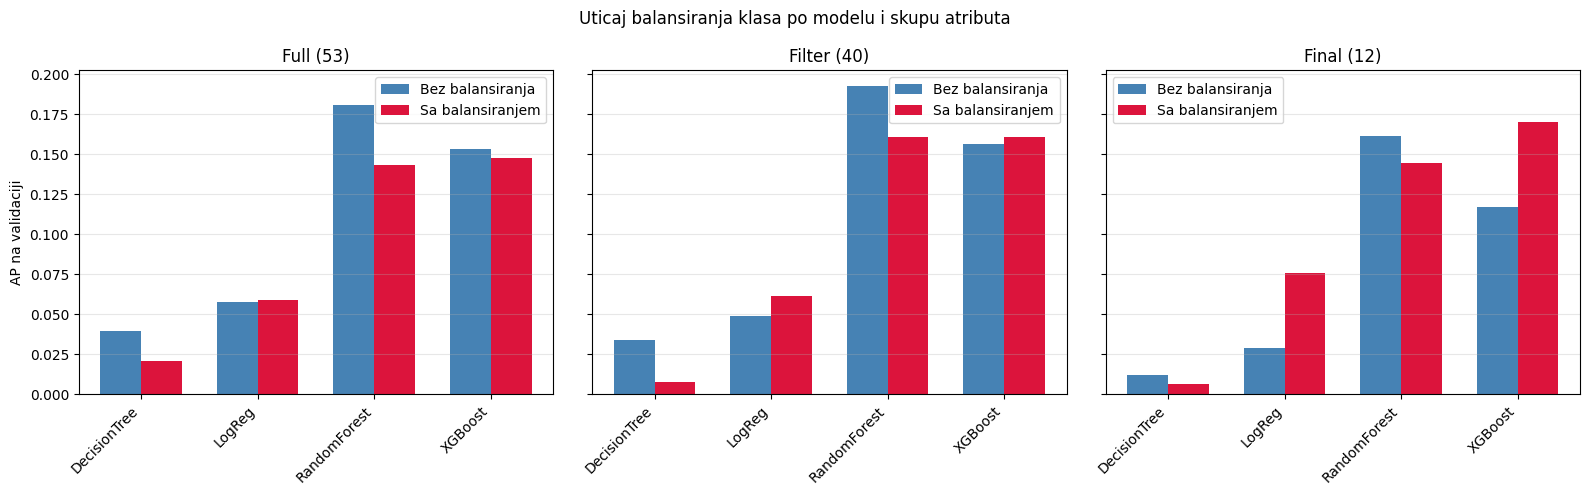

Grafik sačuvan: results/faza4_uticaj_balansiranja.png


In [ ]:
# --- 7. Provera da li balansiranje klasa zaista pomaže ---
# Empirijska provera umesto pretpostavke, isti modeli (class_weight kod
# LogReg/DecisionTree/RandomForest, scale_pos_weight kod XGBoost) se
# treniraju sa i bez balansiranja, na finalnom skupu atributa.
PROVERA = ["LogReg", "DecisionTree", "RandomForest", "XGBoost"]

rezultati_balans = []
for naziv_skupa, d in datasets.items():
    for balansiranje in (True, False):
        modeli = make_models(balansiranje=balansiranje)
        for naziv_modela in PROVERA:
            _, ap_v, _ = evaluate_model(
                modeli[naziv_modela], d["X_train"], y_train, d["X_val"], y_val
            )
            rezultati_balans.append(
                {
                    "Skup": naziv_skupa,
                    "Model": naziv_modela,
                    "Balansiranje": "da" if balansiranje else "ne",
                    "AP val": round(ap_v, 4),
                }
            )

balans_rezultati = pd.DataFrame(rezultati_balans).pivot(
    index=["Skup", "Model"], columns="Balansiranje", values="AP val"
)
balans_rezultati["razlika"] = (balans_rezultati["da"] - balans_rezultati["ne"]).round(4)
print("Uticaj balansiranja klasa (AP na validaciji, sva tri skupa atributa):")
print(balans_rezultati.to_string())

balans_rezultati.to_csv(RESULTS / "faza4_uticaj_balansiranja.csv")
print("Sačuvano: results/faza4_uticaj_balansiranja.csv")

# Vizuelizacija: uticaj balansiranja po modelu i skupu atributa
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
skupovi_redosled = list(datasets.keys())

for ax, naziv_skupa in zip(axes, skupovi_redosled):
    podaci = balans_rezultati.loc[naziv_skupa]
    x = np.arange(len(podaci))
    sirina = 0.35
    ax.bar(
        x - sirina / 2,
        podaci["ne"],
        sirina,
        label="Bez balansiranja",
        color="steelblue",
    )
    ax.bar(
        x + sirina / 2, podaci["da"], sirina, label="Sa balansiranjem", color="crimson"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(podaci.index, rotation=45, ha="right")
    ax.set_title(naziv_skupa)
    ax.grid(alpha=0.3, axis="y")
    ax.legend()

axes[0].set_ylabel("AP na validaciji")
plt.suptitle("Uticaj balansiranja klasa po modelu i skupu atributa")
plt.tight_layout()
plt.savefig(RESULTS / "faza4_uticaj_balansiranja.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza4_uticaj_balansiranja.png")


# Za Decision Tree balansiranje uvek šteti (od -0.005 do -0.037), takođe i za Random Forest (od -0.017 do -0.037), što potvrđuje da stabla postaju sklonija overfitting-u na ređoj klasi kada im se dodatno pojača težina te klase. Log Reg  uvek dobija, ali veličina efekta zavisi od skupa. XGBoost je najzanimljiviji: balansiranje pomaže na Final skupu podataka (+0.053), zanemarljiv na Filter-u (+0.005),dok šteti na Full skupu (-0.006). Balansiranje nije univerzalno korisno ni po modelu ni nezavisno od skupa atributa, već efekat zavisi od obe stvari.

In [ ]:
# --- 8. Optimizacija hiperparametara najboljih kandidata ---
# TimeSeriesSplit umesto običnog KFold-a.
# n_splits=3 iz istog razloga kao u Fazi 3 (premalo pozitivnih po
# foldu kod n_splits=5).Optimizuju se samo RandomForest i XGBoost. Svaki model koristi svoju najbolju kombinaciju skupa atributa i balansiranja
# RandomForest bez balansiranja na Filter skupu (AP=0.1928), XGBoost sa
# balansiranjem na Final skupu (AP=0.1703).
kandidati_za_tuning = {
    "RandomForest": {"skup": "Filter (40)", "balansiranje": False},
    "XGBoost": {"skup": "Final (12)", "balansiranje": True},
}

prostor_pretrage = {
    "RandomForest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [5, 10, 15, None],
        "min_samples_leaf": [1, 5, 10, 25, 50, 100],
        "min_samples_split": [2, 10, 25, 50],
        "max_features": ["sqrt", "log2", None],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 5, 10, 20],
        "reg_alpha": [0, 0.1, 1, 5],
        "reg_lambda": [1, 5, 10],
    },
}

tscv = TimeSeriesSplit(n_splits=3)
rezultati_tuning = {}

for naziv_modela, konfig in kandidati_za_tuning.items():
    X_tr = datasets[konfig["skup"]]["X_train"]
    X_v = datasets[konfig["skup"]]["X_val"]
    osnovni_model = make_models(balansiranje=konfig["balansiranje"])[naziv_modela]

    pretraga = RandomizedSearchCV(
        osnovni_model,
        param_distributions=prostor_pretrage[naziv_modela],
        n_iter=30,
        scoring="average_precision",
        cv=tscv,
        random_state=SEED,
        n_jobs=-1,
    )
    pretraga.fit(X_tr, y_train)

    model_opt = pretraga.best_estimator_
    p_val = model_opt.predict_proba(X_v)[:, 1]
    ap_val = average_precision_score(y_val, p_val)

    rezultati_tuning[naziv_modela] = {
        "model": model_opt,
        "skup": konfig["skup"],
        "X_val": X_v,
        "p_val": p_val,
        "ap_val": ap_val,
        "parametri": pretraga.best_params_,
    }
    print(f"{naziv_modela} ({konfig['skup']}): AP val posle tuninga = {ap_val:.4f}")
    print(f"  Najbolji parametri: {pretraga.best_params_}\n")

# Izbor pobednika posle tuninga.
naziv_najboljeg = max(rezultati_tuning, key=lambda m: rezultati_tuning[m]["ap_val"])
model_optimizovan = rezultati_tuning[naziv_najboljeg]["model"]
X_val_najboljeg = rezultati_tuning[naziv_najboljeg]["X_val"]
p_val_opt = rezultati_tuning[naziv_najboljeg]["p_val"]
ap_val_opt = rezultati_tuning[naziv_najboljeg]["ap_val"]

print(
    f"\nNajbolji posle tuninga: {naziv_najboljeg} "
    f"({rezultati_tuning[naziv_najboljeg]['skup']}), AP val = {ap_val_opt:.4f}"
)

# RandomForest posle tuninga dostiže AP=0.2386 značajan skok u odnosu na
# 0.1928 pre tuninga
# XGBoost posle tuninga PADA na AP=0.1503, niže od podrazumevanih parametara
# (0.1703). RandomizedSearchCV bira najbolju kombinaciju na osnovu proseka kroz
# TimeSeriesSplit fold-ove unutar treninga (2, 22, 12 pozitivnih po fold-u), ne
# direktno na validaciji. Kod ovako malog broja pozitivnih po fold-u, kombinacija koja
# pobedi na CV proseku ne mora da generalizuje jednako dobro na pravi
# validacioni skup (druga vremenska populacija, 115 pozitivnih). Ovo je
# poznato ograničenje standardnog tuning-a pod ekstremnim disbalansom.

RandomForest (Filter (40)): AP val posle tuninga = 0.2386
  Najbolji parametri: {'n_estimators': 300, 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 10}

XGBoost (Final (12)): AP val posle tuninga = 0.1503
  Najbolji parametri: {'subsample': 0.85, 'reg_lambda': 5, 'reg_alpha': 5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.85}


Najbolji posle tuninga: RandomForest (Filter (40)), AP val = 0.2386


Najbolji model: RandomForest (Filter (40))
Izabrani prag: 0.091456
Na validaciji -> preciznost: 0.3083, odziv: 0.3565, F1: 0.3306
Uhvaćeno napada: 41 od 115, promašeno: 74
Lažnih uzbuna: 92 ukupno, 23.0 po danu


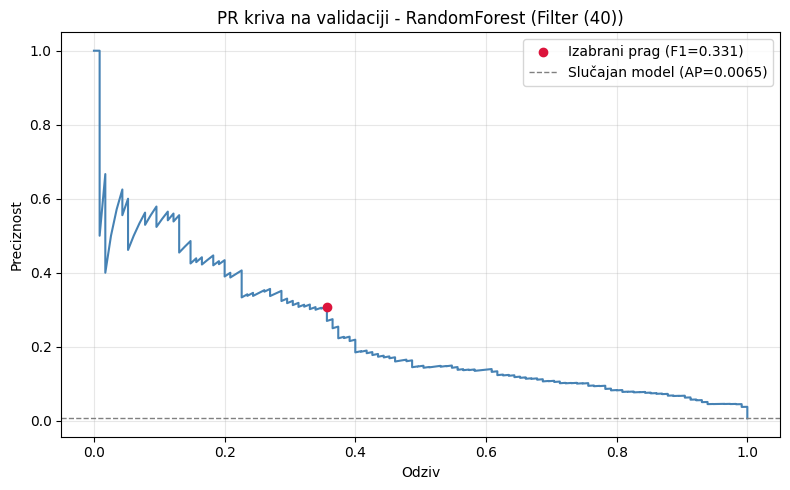

Grafik sačuvan: results/faza4_pr_kriva_validacije.png


In [ ]:
# --- 9. Biranje praga odlučivanja na validaciji ---
# Prag se bira kao vrednost koja maksimizuje F1-meru na validaciji, pa se taj
# isti, fiksni prag kasnije primenjuje na test - bira se unapred, ne unazad
# prema najboljem ishodu na testu.
skup_najboljeg = rezultati_tuning[naziv_najboljeg]["skup"]

preciznost, odziv, pragovi = precision_recall_curve(y_val, p_val_opt)
f1 = 2 * preciznost * odziv / (preciznost + odziv + 1e-12)
najbolji_idx = int(np.argmax(f1[:-1]))
prag = float(pragovi[najbolji_idx])

print(f"Najbolji model: {naziv_najboljeg} ({skup_najboljeg})")
print(f"Izabrani prag: {prag:.6f}")
print(
    f"Na validaciji -> preciznost: {preciznost[najbolji_idx]:.4f}, "
    f"odziv: {odziv[najbolji_idx]:.4f}, F1: {f1[najbolji_idx]:.4f}"
)

y_pred_val = (p_val_opt >= prag).astype(int)
tp = int(((y_pred_val == 1) & (y_val == 1)).sum())
fp = int(((y_pred_val == 1) & (y_val == 0)).sum())
fn = int(((y_pred_val == 0) & (y_val == 1)).sum())
dana_u_validaciji = val["day"].nunique()
print(f"Uhvaćeno napada: {tp} od {int(y_val.sum())}, promašeno: {fn}")
print(f"Lažnih uzbuna: {fp} ukupno, {fp / dana_u_validaciji:.1f} po danu")

plt.figure(figsize=(8, 5))
plt.plot(odziv, preciznost, color="steelblue")
plt.scatter(
    odziv[najbolji_idx],
    preciznost[najbolji_idx],
    color="crimson",
    zorder=5,
    label=f"Izabrani prag (F1={f1[najbolji_idx]:.3f})",
)
plt.axhline(
    y_val.mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Slučajan model (AP={y_val.mean():.4f})",
)
plt.xlabel("Odziv")
plt.ylabel("Preciznost")
plt.title(f"PR kriva na validaciji - {naziv_najboljeg} ({skup_najboljeg})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza4_pr_kriva_validacije.png", dpi=120)
plt.show()
print("Grafik sačuvan: results/faza4_pr_kriva_validacije.png")

# PR kriva pokazuje da je model daleko iznad slučajnog nagađanja (siva linija,
# AP=0.0065) kroz ceo opseg odziva čak i pri visokom odzivu, preciznost
# ostaje veća od slučajnog izbora. Nestabilnost krive na početku (nizak
# odziv) je očekivana: kad model izdvoji samo deo najsumnjivijih prozora,
# jedan jedini pogrešan naglo menja preciznost, jer se kriva
# računa na tako malom broju predikcija. Izabrani prag (F1=0.331, harmonijska sredina
# preciznosti i odziva) se nalazi okvirno na mestu gde kriva menja karakter:
# do te tačke, dodatni odziv se dobija uz relativno mali gubitak preciznosti, a
# posle nje preciznost naglo pada.

In [ ]:
# --- 10. Čuvanje modela i konfiguracije za finalnu evaluaciju ---
# Modeli se čuvaju da bi test evaluacija (kraj Faze 6) mogla da se izvede bez
# ponovnog treniranja i bez dodatnog diranja test skupa.
joblib.dump(model_optimizovan, MODELS / "faza4_najbolji_model.pkl")

konfiguracija = {
    "model": naziv_najboljeg,
    "skup_atributa": skup_najboljeg,
    "kolone": list(X_val_najboljeg.columns),
    "najbolji_parametri": {
        k: str(v) for k, v in rezultati_tuning[naziv_najboljeg]["parametri"].items()
    },
    "prag": prag,
    "ap_validacija": float(ap_val_opt),
}
with open(MODELS / "faza4_konfiguracija.json", "w", encoding="utf-8") as f:
    json.dump(konfiguracija, f, ensure_ascii=False, indent=2)

print("Sačuvano: models/faza4_najbolji_model.pkl")
print("Sačuvano: models/faza4_konfiguracija.json")

Sačuvano: models/faza4_najbolji_model.pkl
Sačuvano: models/faza4_konfiguracija.json
